In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL
)
""")

In [4]:
sample_data = [
    ('Apples', 10, 1.2),
    ('Oranges', 8, 1.5),
    ('Bananas', 15, 0.8),
    ('Apples', 5, 1.2),
    ('Oranges', 12, 1.5),
    ('Bananas', 7, 0.8)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

In [5]:
query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""
df = pd.read_sql_query(query, conn)

In [6]:
print("Sales Summary:\n", df)

Sales Summary:
    product  total_qty  revenue
0   Apples         15     18.0
1  Bananas         22     17.6
2  Oranges         20     30.0


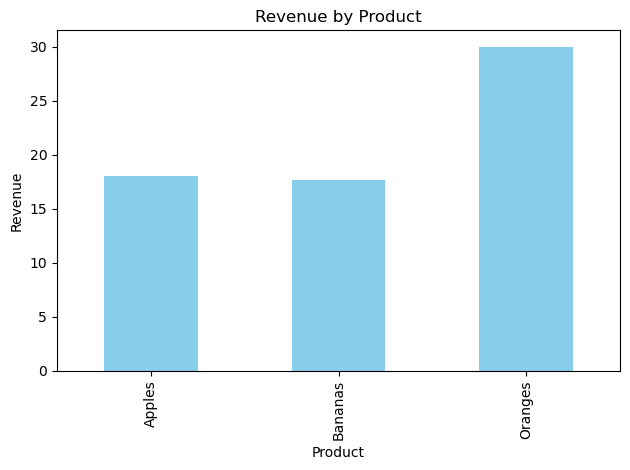

In [7]:
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [8]:
conn.close()